# Design

- Ensure:
    - Quad motors (4 of them) provide enough thrust (in grams) to lift the quadcopter at 50% throttle

## Motors

| Constant | Symbol | Unit         | Description | 
|----------|--------|--------------|-------------|
| Motor    | $Km$   | Nm/$\sqrt W$ | 
| Velocity | $Kv$   | rpm/V        | rpm per volt with no load
| Torque   | $Kt$   | Nm/A         | torque per Amp

$$
\begin{align}
\tau &= F \cdot r \\
  &= \frac {B^2}{\mu_o} \pi r^2 h \\
  \\
\tau &= K_M \cdot \sqrt{P} \\
     &= K_T \cdot I \\
     &= \left( \frac {60}{2\pi} \right) \frac {I}{K_v} \\
     \\
K_T &= \left( \frac {60}{2\pi} \right) \frac {1}{K_v} \\ 
\\
rpm &= voltage \cdot Kv \\
\end{align}
$$

where $P$ is the resistive power loss.

- For motors with good quality control and manufacturing processes, $\frac{B^2}{\mu_o}$ are all the same
- Torque is really a function of motor volume
- Kv
    - A coefficient to describe RPM based off of voltage
    - For the same sized propeller (e.g., 2315) and motor (e.g., 1104):
        - **Low Kv:** Low RPM, high current, more heat
        - **High Kv:** High RPM, low current, lower heat

## Same Size Motor with Kv Differences

![](./Happymodel-1204.webp)

Looking at 133 g of thrust for the Happymodel 1204, both using the GF 3025-2 propeller:

| 1204 Kv @ 133g Thrust | A | V    | Watts | RPM    | Eff |Throttle
|-----------------------|---|------|-------|--------|-----|----------|
| 5000                  | 3 | 14.8 | 44.4  | 55,937 | 3   | 75.6%
| 6500                  | 4 | 11.1 | 44.4  | 56,145 | 3   | 77.8%

Both of these are set to the same thrust and will give the same torque. We can
see:

- **Lower Kv:**
    - Higher voltage needed to achieve same electrical power and efficiency
    - Lower current, cooler motors, lower throttle settings
    - Since the **same** thrust (and torque) can be achieved at a lower throttle, ultimately, this motor can achieve a higher thrust/torque than the other motor
    - Thicker (higher guage) wire, can carry more current
    - Larger quads moving to higher voltages to reduce current through motors and keep motors cooler
- **Higher Kv:**
    - Lower voltage needed, allowing 1S, 2S size batteries to be used
    - Higher current, hotter motors especially when more torque/thrust needed

Initially, small quads used 1S or 2S batteries, so high Kv was needed to get them
to fly. As quads get bigger or more agility is needed, quads have moved to 3S, 4S,
6S and even 8S to keep motors cooler.

## Different Size Motor with Same Kv

Increasing motor size (e.g., moving from 1104 to 1204) increases torque. Motor torque
is a function of motor volume due to the amount of copper wire inside the motor. 

## Propellers

![](https://www.aerodynamics4students.com/propulsion/propeller1.png)
![](https://www.aerodynamics4students.com/propulsion/propeller2.png)

$$
\begin{align}
tipSpeed &= rpm \cdot \frac {2 \pi}{60} \frac {prop_{Dia}}{2} \cdot 0.0254 / 343 \\
drag &= C_d \cdot \rho \frac {V}{2}^2 \cdot A \\
torque &= \frac {1}{2} \rho V^2 c \left[ C_L \cos(\phi) - C_D \sin(\phi) \right] \cdot B \cdot R
\end{align}
$$

| Var | Def |
|---|---|
| $\phi$ | Pitch angle
| $B$ | Number of blades on the propeller
| $c$ | Blade chord
| $C_d$ | Coefficient of drag for a generic body through a fluid
| $C_D$ | Coefficient of propeller drag
| $C_L$ | Coefficient of propeller lift
| $\rho$ | Density of fluid
| $V$ | Velocity
| $A$ | Reference area, or cross sectional area perpendicular to the velocity
| $R$ | Blade radial length from the hub

- want to keep the tip speed below 0.6 Mach (343 m/s) to avoid compressable air effects
- more blades reduces efficiency due to turbulent flow
- Each blade adds more thrust up to a point (flow becomes too turbulent or physically cannot add more blades)

Tip speed units transformed into a Mach ratio:

$$
\begin{align}
rpm &= voltage \cdot Kv \\
radsPerSec &= \frac {2 \pi}{60} \\
prop_{m} &= \frac {prop_{Dia}}{2} \cdot 0.0254 \\
mach_{mps} &= 343 \\
tipSpeed &= rpm \cdot radsPerSec \cdot prop_{m} / mach_{mps}
\end{align}
$$

Just to make units conversion clearer:

$$
\begin{align}
vel &= \omega \cdot r \\
tipSpeed_{m/sec} &= \left( \frac {rev}{min} \frac {min}{60sec} \frac {2 \pi}{rev} \right) \cdot in \frac {0.0254m}{in} \\
tipSpeed_{mach} &= \frac {m/sec}{343 m/sec}
\end{align}
$$

## Batteries

So **increased** battery voltage reduces motor Kv and motor heat (due to reduced current),
but adds ~22.5 g per battery cell.

| Brand 1100mAh/60C | Grams | Normalize | Watts |
|-------------------|-------|-----------|-------|
| GNB 3S            | 71    | 23.7      | 12.21 |
| GNB 4S            | 92    | 23.0      | 16.28 |
| GNB 5S            | 109   | 21.8      | 20.35 |
| GNB 6S            | 130   | 21.7      | 24.42 |

Maybe instead of increasing the number of cells, keep the power the same and 
get a smaller mAh pack. Unfortunately, smaller packs are less efficient per
Watt, so they are heaver than larger packs.

| GNB 6S mAh | Watts | Grams | g/W |
|------------|-------|-------|-----|
| 650        | 14.43 | 100   | 6.9
| 850        | 18.87 | 103   | 5.5
| 1100       | 24.42 | 130   | 5.3

## Challenges

- I want:
    - ensure: motor torque >= propeller drag (@ max rpm)
        - problem: I can't calculate motor torque because I don't know $\frac{B^2}{\mu_o}$ and I don't know the drag coefficients for the propeller
        - Best I can do is find commercial quads and use their parts (props, motors, batteries, etc) as a basis of what will work
    - account for different types of propellers
        - problem: motor testing tables are only valid for the  propellers they used in the testing. How can I account for different propllers (2" instead of 4" or 4 blade instead of 2 blades) reliably. I can normalize the results to say 1", 1 blade and compare performance, but, **is that valid?** How do I account for blade pitch?

## Notes

- See Chris Rosser's "MASSIVE 65mm Tiny Whoop Motor Test!" on [YouTube](https://www.youtube.com/watch?v=3wsGKrETTxg)
    - RCinPower makes good Tiny Whoop motors (0702/0803 sizes)
    - HappyModel and T-Motor are pretty bad

# References

- [Aerodynamics for Students: Propulsion](https://www.aerodynamics4students.com/propulsion/blade-element-propeller-theory.php)
- Wikipedia: [Motor Constants](https://en.wikipedia.org/wiki/Motor_constants)


In [1]:
import pandas as pd
import numpy as np
from collections import namedtuple
from matplotlib import pyplot as plt

Design = namedtuple("Design", "prop_in kv s")
RefDesign = namedtuple("RefDesign","rpm tip_speed kv ref")

In [427]:
print(f"motors@50%: {250 / 4} g motors@100%: {2*250 / 4} g")

motors@50%: 62.5 g motors@100%: 125.0 g


In [425]:
data = {
    'Motor': [],
    'Torque': [],
    'Diff': []
}

def percentDiff(x,ref):
    return int(100*(x-ref)/ref)

def calcT(x):
    return int(((x//100)/2)**2 * np.pi * (x%100))

ref = None
for x in [1104,1106,1202.5,1204,1303,1303.5,1306,1404,1504,1506,1603,1804,2004,2205]:
    if ref is None:
        ref = calcT(x)
    data['Motor'].append(int(x))
    T = calcT(x)
    data['Torque'].append(T)
    data['Diff'].append(percentDiff(T, ref))

df = pd.DataFrame(data)
df

,Motor,Torque,Diff
0,1104,380,0
1,1106,570,50
2,1202,282,-25
3,1204,452,18
4,1303,398,4
5,1303,464,22
6,1306,796,109
7,1404,615,61
8,1504,706,85
9,1506,1060,178


In [438]:
def tip_speed(prop_in,kv,s):
    mach = 343 # speed of sound in m/s at sea level
    rpm = kv*s*3.7 # assume cell is 3.7V
    tip = rpm * 2*np.pi/60 * (prop_in/2)*0.0254 / mach # mach number at sea level
    return tip

def design_in(prop_in, kv_ref, s_ref):
    kv = {}
    rpm = kv_ref*s_ref*3.7 # assume cell is 3.7V
    tip = tip_speed(prop_in,kv_ref,s_ref)

    # scale reference quadcopter to other batteries and find
    # the new Kv
    for s in [2,3,4,6,8]:
        kv[s] = int(kv_ref*s_ref / s)
    return RefDesign(rpm,tip,kv, Design(prop_in, kv_ref, s_ref))

def design_mm(prop_mm, kv, s):
    return design_in(prop_mm/25.4, kv, s)

print("Pavo25v2: ", design_in(2.5,4200,4))
print("CinApe25: ", design_in(2.5,3600,4))

Pavo25v2:  RefDesign(rpm=62160.0, tip_speed=0.6025446481313648, kv={2: 8400, 3: 5600, 4: 4200, 6: 2800, 8: 2100}, ref=Design(prop_in=2.5, kv=4200, s=4))
CinApe25:  RefDesign(rpm=53280.0, tip_speed=0.5164668412554556, kv={2: 7200, 3: 4800, 4: 3600, 6: 2400, 8: 1800}, ref=Design(prop_in=2.5, kv=3600, s=4))


In [184]:
def setMetadata(name,size,kv,weight,motor,prop):
    df = pd.DataFrame(motor)
    df.attrs["size"] = size
    df.attrs["kv"] = kv
    df.attrs["name"] = name
    df.attrs["torque"] = calcT(size)
    df.attrs["weight"] = weight
    df.attrs["prop"] = prop
    return df

In [436]:
Perf = namedtuple("Perf", "throttle current_A thrust_g power_W eff")

motor = [
    Perf(50,4.01,152.17,63.40,2.40),
    Perf(70,7.81,269.82,121.76,2.22),
    Perf(80,10.14,341.23,156.87,2.18),
    Perf(100,14.57,491.41,222.92,2.2)
]
m3900 = setMetadata("iFlight",1504,3900,12.3,motor,"GF 4030")

motor = [
    Perf(50,4.93,204.87,78.19,2.62),
    Perf(70,9.39,342.65,147.05,2.33),
    Perf(90,16.85,531.39,261.68,2.03),
    Perf(100,18.96,579.46,293.5,1.97)
]
m3100 = setMetadata("iFlight",1504,3100,12.3,motor,"GF 4030")

motor = [
    Perf(30,0.51,29,6.1,4.71),
    Perf(40,1.25,58,15.04,3.85),
    Perf(50, 2.29,82,27.51,2.99),
    Perf(70,4.36,137,52.32,2.63),
    Perf(100,10.20,234,122.45,1.91)
]
lava_1104_7200 = setMetadata("Lava",1104,7200,5.3,motor,"GF 2218-3")

motor = [
    Perf(30,1.32,47,21.14,2.22),
    Perf(40,2.58,87,41.2,2.11),
    Perf(50,4.27,148,68.31,2.17),
    Perf(70,8.57,261,137.16,1.9),
    Perf(80,11.78,331,188.48,1.76),
    Perf(90,15.09,400,241.43,1.66),
    Perf(100,19.59,497,311.44,1.59)
]
lava_1506_4200 = setMetadata("Lava",1506,4200,13.6,motor,"GF D63-3")

motor = [
    Perf(50,5.05,327,121.17,2.7),
    Perf(70,10.38,541,249.11,2.17),
    Perf(100,23.49,1013,563.82,1.8)
]
lava_2006_2400 = setMetadata("Lava",2006,2400,22.2,motor,"GF 2218-3")

motor = [
    Perf(int(100*1635/2200),1,38.7,11.1,3.486),
    Perf(100,7.9,207.6,87.69,2.367)
]
happymodel_1105_5200 = setMetadata("Happymodel",1105,5200,5.7,motor,"GF 3025-2")

motor = [
    Perf(int(100*1374/2200),1,57,14.8,3.851),
    Perf(100,7,227.6,103.6,2.197)
]
happymodel_1204_5000 = setMetadata("Happymodel",1204,5000,5.9,motor,"GF 3025-2")

motor = [
    Perf(50,1.41,58.85,17.2,3.42),
    Perf(100,5.63,156.57,68.06,2.3)
]
tmotor_1204_5000 = setMetadata("T-Motor",1204,5000,6.9,motor,"GF 2540-3")

motor = [
    Perf(20,1.4,104.1,35.4,2.94),
    Perf(100,15.8,618.8,394.6,1.57)
]
tmotor_1604_2850 = setMetadata("T-Motor",1604,2850,11.8,motor,"GF 3520-3")

motors = [
    # m3900,
    # m3100,
    lava_1104_7200,
    lava_1506_4200,
    lava_2006_2400,
    happymodel_1105_5200,
    happymodel_1204_5000,
    tmotor_1204_5000,
    tmotor_1604_2850
]

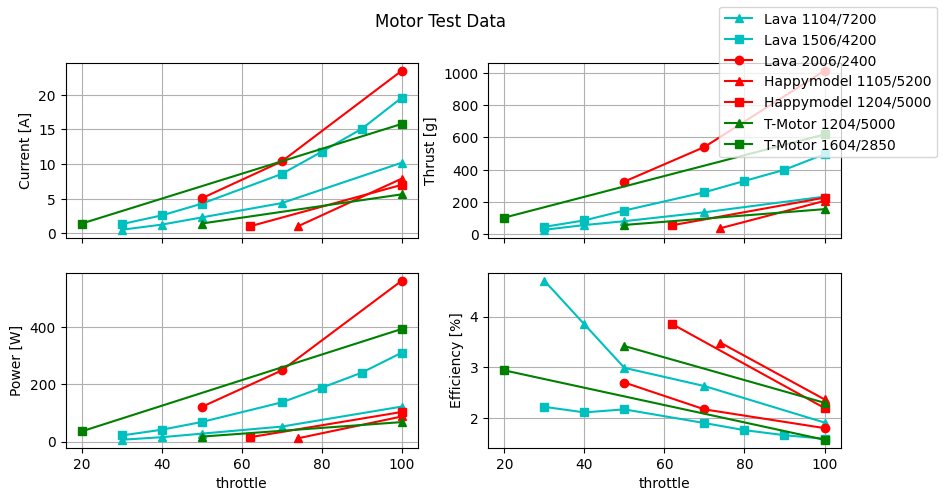

In [433]:
fig,ax = plt.subplots(2,2,figsize=(10,5), sharex=True)
legend = []

# m3900.plot(x="throttle",subplots=True, ax=ax, style="c^-", legend=False);
# m3100.plot(x="throttle",subplots=True, ax=ax, style="cs-", legend=False);
# lava_1104_7200.plot(x="throttle",subplots=True, ax=ax, style="ro-", legend=False);
# lava_1506_4200.plot(x="throttle",subplots=True, ax=ax, style="r^-", legend=False);
# lava_2006_2400.plot(x="throttle",subplots=True, ax=ax, style="rs-", legend=False);
# fig.legend([
#     "iFlight 1504/3900",
#     "iFlight 1504/3100",
#     "Lava 1104/7200",
#     "Lava 1506/4200",
#     "Lava 2006/2400"
# ])

# kind of sucks I have to do this, but DataFrame make all the colors the
# same for each plot ... stupid!
styles = [
    "c^-",
    "cs-",
    "ro-",
    "r^-",
    "rs-",
    "g^-",
    "gs-",
    "b^-"
]

for df,s in zip(motors, styles):
    df.plot(x="throttle",subplots=True, ax=ax, style=s, legend=False);
    d = df.attrs
    legend.append(f"{d['name']} {d['size']}/{d['kv']}")

ax[0,0].set_ylabel("Current [A]")
ax[0,1].set_ylabel("Thrust [g]")
ax[1,0].set_ylabel("Power [W]")
ax[1,1].set_ylabel("Efficiency [%]")

fig.legend(legend)

# Why can't you turn the grids for all of these on at
# once??
for i in [0,1]:
    for j in [0,1]:
        ax[i,j].grid(True);

fig.suptitle("Motor Test Data");

## Motor Thrust Spline

Create a spline based on the motor thrust testing.

In [353]:
def interp1d(xp, yp):
    func = interp1dfunc(xp,yp)
    return func

class interp1dfunc:
    """
    This is what I want, but they deprecated it, so I am making
    my own 1D interpolate class

    https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d

    This now uses the numpy function (which feels less efficient):

    https://numpy.org/devdocs/reference/generated/numpy.interp.html#numpy.interp
    """
    def __init__(self, xp, yp):
        self.xp = np.copy(xp)
        self.yp = np.copy(yp)

    def __call__(self, x):
        if np.any(x > 100.0) or np.any(x < 0.0):
            raise Exception("Thrust inputs must be between 0-100")

        return np.interp(x, self.xp, self.yp)

In [354]:
def makeThrustInterp(df):
    # breakout throttle and thrust
    x = df["throttle"].to_numpy()
    y = df["thrust_g"].to_numpy()

    # test data doesn't include (0,0) and often not much
    # below 50% throttle
    x = np.concatenate([[0],x])
    y = np.concatenate([[0],y])

    return interp1d(x,y)

def plotThrust(df):
    # plot
    new_x = np.linspace(0, 100, 100)
    thrust_func = makeThrustInterp(df)
    new_y = thrust_func(new_x)

    xp = thrust_func.xp
    yp = thrust_func.yp

    plt.plot(new_x,new_y,"b-")
    plt.plot(xp,yp,"r^")
    name = df.attrs["name"]
    size = df.attrs["size"]
    kv = df.attrs["kv"]
    prop = df.attrs["prop"]
    plt.title(f"{name} {size}/{kv} {prop}")
    plt.ylabel("Thrust [g]")
    plt.xlabel("Throttle [%]")
    plt.grid(True)


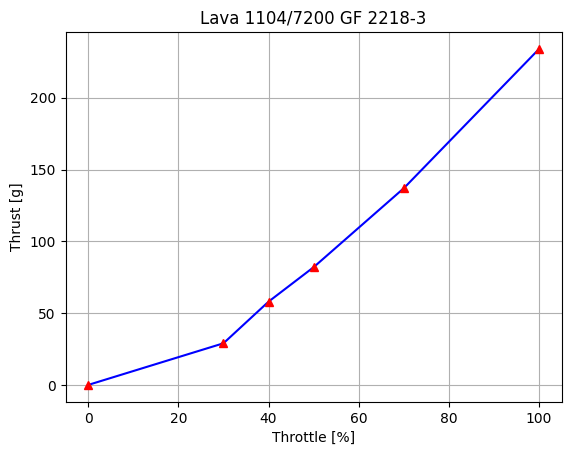

In [355]:
plotThrust(lava_1104_7200)

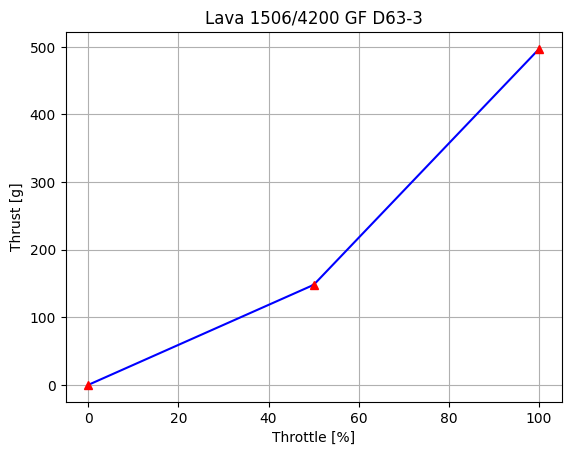

In [350]:
plotThrust(lava_1506_4200)

In [434]:
rd = lava_1104_7200.attrs
ref = rd["torque"] / rd["weight"]

print(f"{'Motor':15}{'Torque':7}{'Weight':7}{'Tor/g':7}{'%diff':5} {'Thrust':5} {'Thr/g':7}")
print("-"*60)
for m in motors:
    thrust = m.loc[m["throttle"]==100,"thrust_g"].values[0]
    d = m.attrs
    T = d["torque"]
    g = d["weight"]
    l = f"{d['name']}-{d['size']}"
    print(f"{l:15} {T:5} {g:5} {T/g:5.1f}{percentDiff(T/g, ref):7} {thrust:7.0f} {thrust/g:5.1f}")

Motor          Torque Weight Tor/g  %diff Thrust Thr/g  
------------------------------------------------------------
Lava-1104         380   5.3  71.7      0     234  44.2
Lava-1506        1060  13.6  77.9      8     497  36.5
Lava-2006        1884  22.2  84.9     18    1013  45.6
Happymodel-1105   475   5.7  83.3     16     208  36.4
Happymodel-1204   452   5.9  76.6      6     228  38.6
T-Motor-1204      452   6.9  65.5     -8     157  22.7
T-Motor-1604      804  11.8  68.1     -4     619  52.4


In [435]:
lava_1104_7200

,throttle,current_A,thrust_g,power_W,eff
0,30,0.51,29,6.10,4.71
1,40,1.25,58,15.04,3.85
2,50,2.29,82,27.51,2.99
3,70,4.36,137,52.32,2.63
4,100,10.20,234,122.45,1.91


In [423]:
lava_1104_7200.loc[lava_1104_7200["throttle"]==100,"thrust_g"].values[0]

np.int64(234)

In [2]:
60/(2*np.pi)

9.549296585513721